In [ ]:
import os
if not os.path.exists ('DHSI_2026_CTA'):
    !git clone https://github.com/JacekBakowski/DHSI_2026_CTA.git
%cd /content/DHSI_2026_CTA/Topic_Modeling

In [3]:
%pip install gensim
%pip install pyldavis
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
warnings.filterwarnings ('ignore', category = DeprecationWarning)

In [14]:
import os
from toolbox_tm import *
from pathlib import Path

PATH_100_NOVELS = Path ("../corpora/100_English_Novels/raw/corpus")
PATH_100_NOVELS_LEMMA = Path ("../corpora/100_English_Novels/lemmatized/corpus")
PATH_SMALL_COLLECTION = Path ('../corpora/A_Small_Collection_of_British_Fiction/lemmatized/corpus')
PATH_SHAKESPEARE = Path ('../corpora/shakespeare')

#### Loading the corpus

In [15]:
processed = load_corpus (PATH_100_NOVELS, exclude_stop_words= True, drop_ners = True)

# Quick look at what one document looks like after processing
first_doc = next(iter(processed))
print(f"\nFirst document: {first_doc}")
print(f"First 20 tokens: {', '.join (processed[first_doc][:20])}")

Loaded 100 documents, 5,764,633 tokens total.

First document: Anon_Clara_1864.txt
First 20 tokens: mean, describe, feel, personal, pronoun, appear, often, pages, faults, character, almost, well, best, friends, know, shall, attempt, hide, would, beloved


#### Building the vocabulary

In [6]:
dictionary = build_dictionary (processed, min_df = 3, max_df = 0.7)

Vocabulary: 96,020 unique words -> 34,750 after filtering
  Kept words appearing in at least 3 document(s) and at most 70% of 100 documents.


#### Fitting the LDA model

In [23]:
lda_model = fit_lda (processed, dictionary, num_topics = 50, passes=15, alpha = .7)

Training LDA: num_topics=50, passes=15 alpha: 0.7...
Done. Model has 50 topics over a vocabulary of 34,750 words.


#### Visualizing results

In [16]:
top_words_per_topic(lda_model, n = 5)

+---------+----------------+------------------+-----------------+----------------+--------------+
| Topic   | #1             | #2               | #3              | #4             | #5           |
+---------+----------------+------------------+-----------------+----------------+--------------+
| Topic 0 | thou (0.019)   | thee (0.018)     | thy (0.009)     | folk (0.003)   | hast (0.003) |
| Topic 1 | squire (0.003) | aunt (0.002)     | captain (0.002) | parson (0.002) | papa (0.001) |
| Topic 2 | toward (0.001) | guardian (0.001) | aunt (0.001)    | farm (0.001)   | papa (0.001) |
+---------+----------------+------------------+-----------------+----------------+--------------+


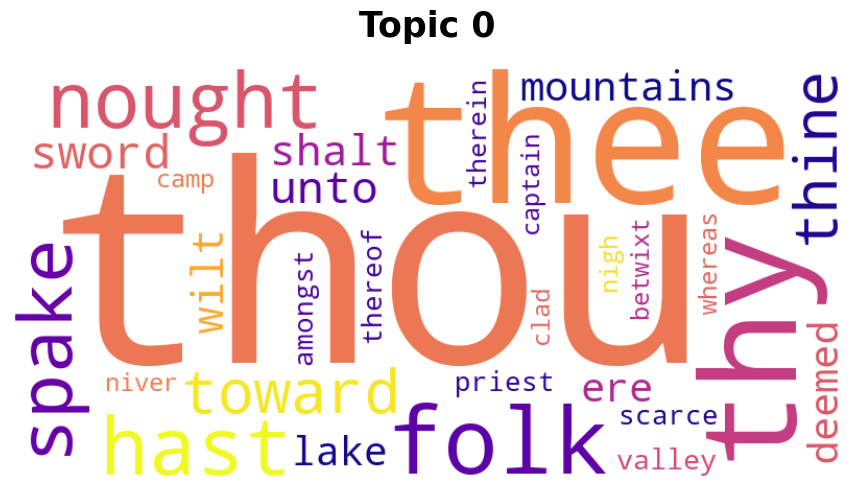

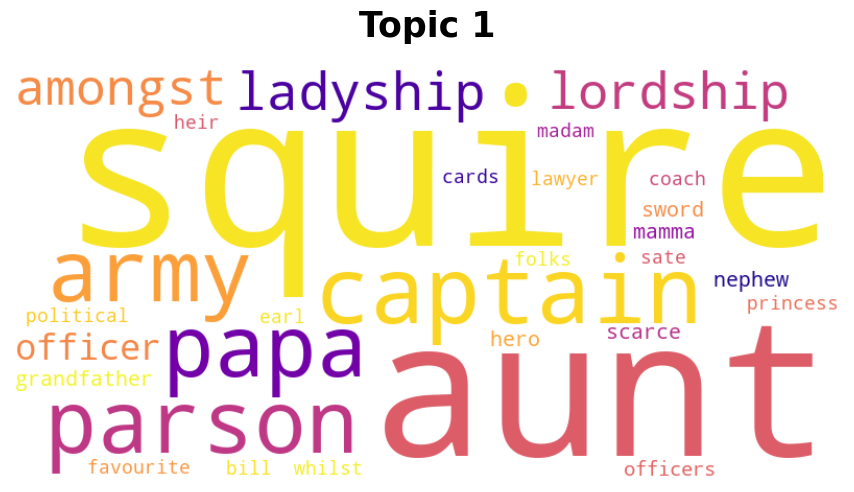

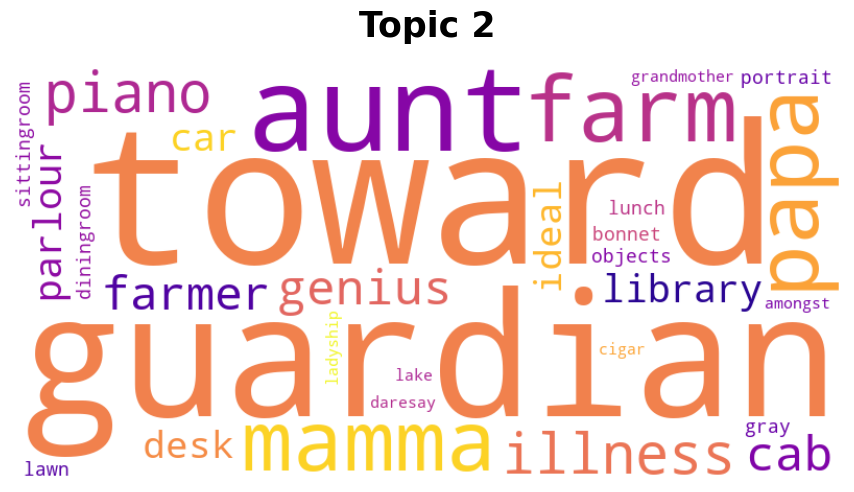

In [9]:
topic_wordclouds (lda_model, max_words = 30, colormap = 'plasma')

In [17]:
top_documents_per_topic (lda_model, processed, dictionary, n=3)

+---------+----------------------------------------+------------------------------------+--------------------------------------+
| Topic   | Doc 1                                  | Doc 2                              | Doc 3                                |
+---------+----------------------------------------+------------------------------------+--------------------------------------+
| Topic 0 | Morris_Roots_1890.txt (100.0%)         | Morris_Water_1897.txt (100.0%)     | Morris_Wood_1894.txt (100.0%)        |
| Topic 1 | Thackeray_Virginians_1859.txt (100.0%) | Thackeray_Esmond_1852.txt (100.0%) | Thackeray_Pendennis_1850.txt (99.2%) |
| Topic 2 | Bennet_Imperial_1930.txt (100.0%)      | Woolf_Night_1919.txt (100.0%)      | James_Ambassadors_1903.txt (100.0%)  |
+---------+----------------------------------------+------------------------------------+--------------------------------------+


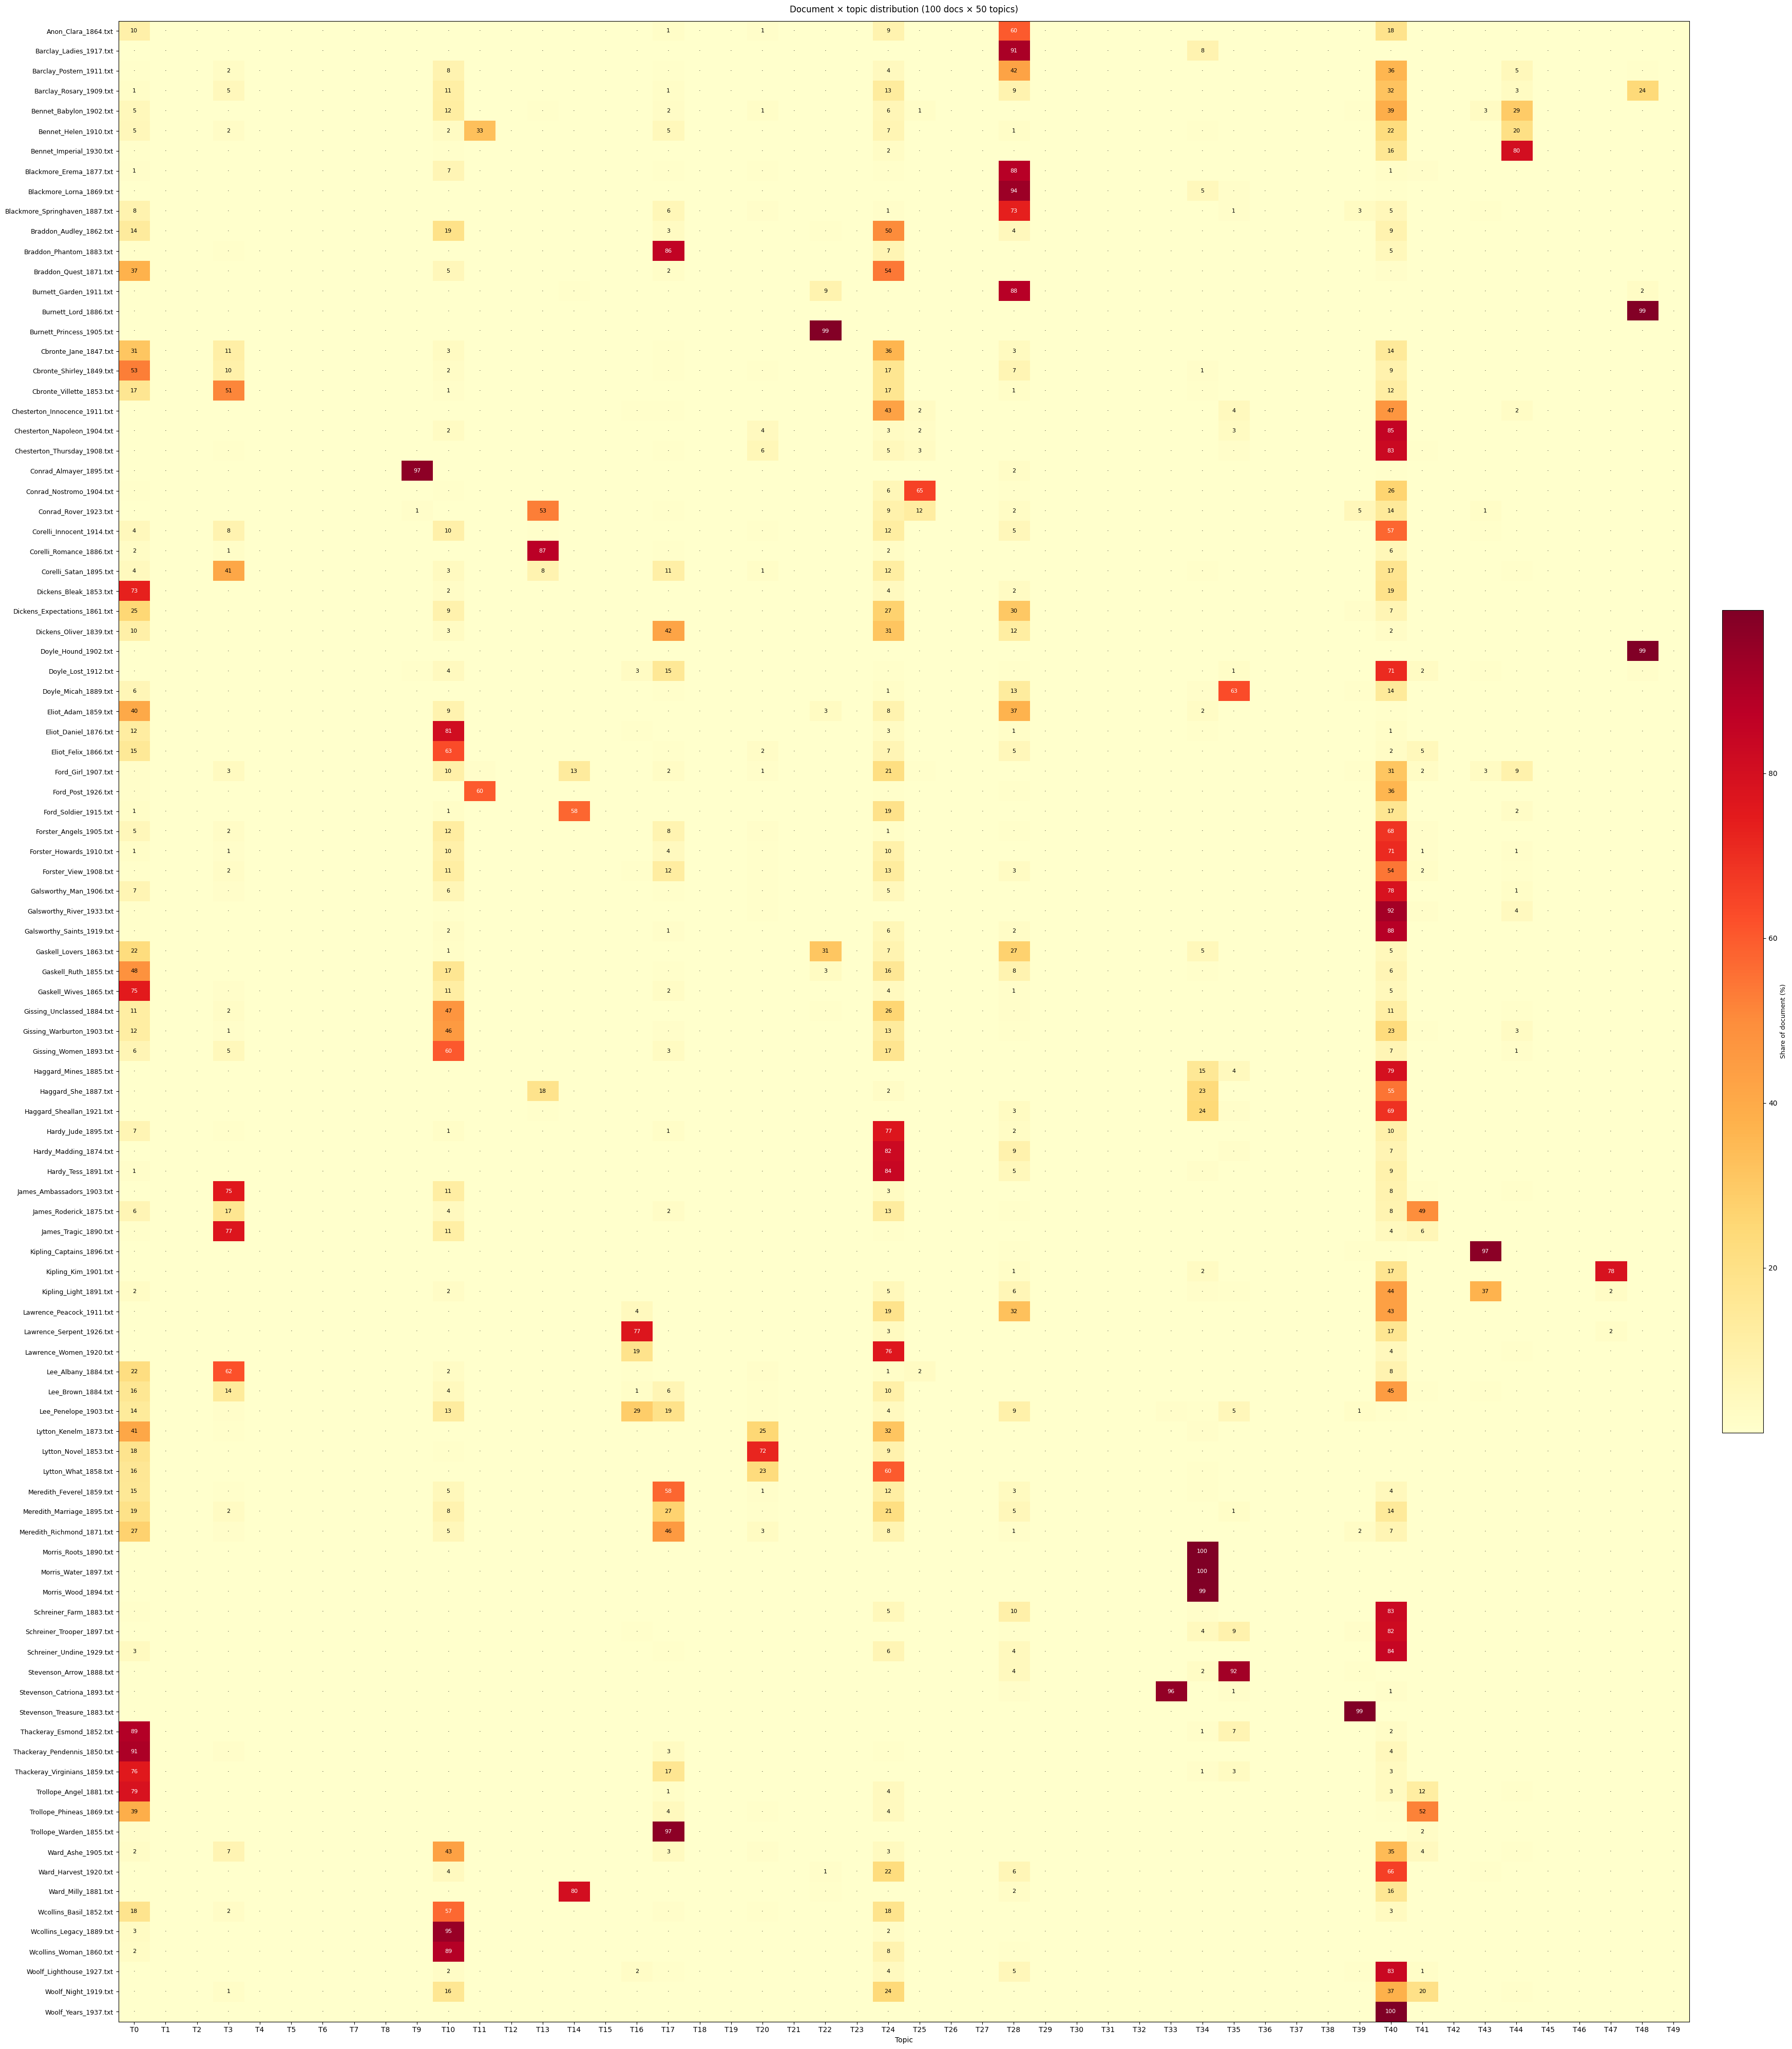

In [24]:
fig = document_topic_heatmap(lda_model, processed, dictionary)

In [ ]:
check_coherence (lda_model, processed, dictionary)

Training LDA: num_topics=2, passes=15 ...
Done. Model has 2 topics over a vocabulary of 34,750 words.
Training LDA: num_topics=4, passes=15 ...
Done. Model has 4 topics over a vocabulary of 34,750 words.
Training LDA: num_topics=3, passes=15 ...
Done. Model has 3 topics over a vocabulary of 34,750 words.
Training LDA: num_topics=5, passes=15 ...
Done. Model has 5 topics over a vocabulary of 34,750 words.


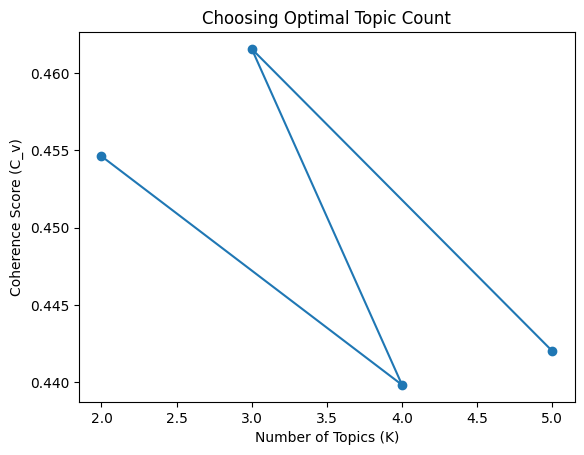

In [28]:
target_range = [2, 4, 3, 5]
find_optimal_coherence (processed, dictionary, target_range)

In [25]:
def generate_html (model, processed, dictionary, filename = 'lda_visualization.html'):
    documents = list(processed.values())
    bow_corpus = [dictionary.doc2bow(doc) for doc in documents]
    vis_data = gensimvis.prepare (
        topic_model = model,      # Your trained Gensim LdaModel or LdaMulticore
        corpus = bow_corpus,              # The Bag-of-Words corpus used for training
        dictionary = dictionary,      # The Gensim Dictionary object
        sort_topics = True            # Sorts topics by total document frequency
    )

    # 2. Display the interactive chart directly inside a Jupyter Notebook
    pyLDAvis.enable_notebook ()
    pyLDAvis.display (vis_data)

    # 3. Alternative: Save the visualization as a standalone HTML file
    # This is perfect for sharing results with colleagues or embedding in a research folder
    pyLDAvis.save_html (vis_data, filename)
generate_html (lda_model, processed, dictionary)

In [ ]:
target_text = list (processed.items ())[0]
raw_tokens = target_text[1]
print (target_text[0])
top_thematic_ids = get_dominant_topics (raw_tokens, lda_model, dictionary, top_n = 3)
data_matrix, timelines = rolling_topic_distribution (raw_tokens, lda_model, dictionary, target_topics = top_thematic_ids, no_steps = 12)
plot_topic_trajectory (data_matrix, timelines, lda_model, target_text[0])